In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import ast

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

def parse_dict_string(dict_str):
    """Parse the Julia-style Dict string into a Python dict."""
    # Replace Dict( with { and ) with }
    dict_str = dict_str.replace('Dict(', '{').replace(')', '}')
    # Replace => with :
    dict_str = dict_str.replace(' => ', ': ')
    return ast.literal_eval(dict_str)

def load_csv_file(filepath):
    """Load a CSV file and parse the nested dict structure."""
    df = pd.read_csv(filepath, header=None, names=['param', 'data'])
    
    # Parse the dict string
    data_dict = parse_dict_string(df['data'].iloc[0])
    
    # Convert to DataFrame: rows=iterations, columns=agents
    iterations = sorted(data_dict.keys())
    agents = sorted(data_dict[iterations[0]].keys())
    
    result = pd.DataFrame(
        [[data_dict[iter][agent] for agent in agents] for iter in iterations],
        columns=[f'Agent_{agent}' for agent in agents],
        index=[f'Iter_{iter}' for iter in iterations]
    )
    
    return result

def plot_single_file(filepath, show_individual=True, show_average=True):
    """Plot completion times for a single file."""
    data = load_csv_file(filepath)
    filename = Path(filepath).name
    
    fig, axes = plt.subplots(1, 2 if show_individual and show_average else 1, 
                             figsize=(18 if show_individual and show_average else 10, 6))
    if not (show_individual and show_average):
        axes = [axes]
    
    plot_idx = 0
    
    # Plot individual iterations
    if show_individual:
        ax = axes[plot_idx]
        x = np.arange(len(data.columns))
        width = 0.15
        
        for i, iter_name in enumerate(data.index):
            offset = (i - 2) * width
            ax.bar(x + offset, data.loc[iter_name], width, 
                   label=iter_name, alpha=0.8)
        
        ax.set_xlabel('Agent', fontsize=12)
        ax.set_ylabel('Completion Time', fontsize=12)
        ax.set_title(f'Individual Iterations - {filename}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(data.columns, rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plot_idx += 1
    
    # Plot averages with error bars
    if show_average:
        ax = axes[plot_idx]
        means = data.mean(axis=0)
        stds = data.std(axis=0)
        x = np.arange(len(means))
        
        bars = ax.bar(x, means, yerr=stds, capsize=5, alpha=0.7, 
                      color='steelblue', ecolor='black')
        
        ax.set_xlabel('Agent', fontsize=12)
        ax.set_ylabel('Average Completion Time', fontsize=12)
        ax.set_title(f'Average ± Std Dev - {filename}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(data.columns, rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + std,
                   f'{mean:.1f}±{std:.1f}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    #plt.show()
    
    return fig

def compare_files(filepaths, labels=None):
    """Compare average completion times across multiple files."""
    if labels is None:
        labels = [Path(fp).name for fp in filepaths]
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    x = np.arange(8)  # 8 agents
    width = 0.8 / len(filepaths)
    
    for i, (filepath, label) in enumerate(zip(filepaths, labels)):
        data = load_csv_file(filepath)
        means = data.mean(axis=0)
        stds = data.std(axis=0)
        
        offset = (i - len(filepaths)/2 + 0.5) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=3,
               label=label, alpha=0.8)
    
    ax.set_xlabel('Agent', fontsize=12)
    ax.set_ylabel('Average Completion Time', fontsize=12)
    ax.set_title('Comparison of Average Completion Times', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Agent_{i+1}' for i in range(8)])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def compare_folders(folder1, folder2, pattern='*.csv', exclude_collision=True):
    """Compare matching files between two folders."""
    folder1_path = Path(folder1)
    folder2_path = Path(folder2)
    
    files1 = {f.name: f for f in folder1_path.glob(pattern)}
    files2 = {f.name: f for f in folder2_path.glob(pattern)}
    
    if exclude_collision:
        files1 = {k: v for k, v in files1.items() if not k.startswith('collision')}
        files2 = {k: v for k, v in files2.items() if not k.startswith('collision')}
    
    common_files = set(files1.keys()) & set(files2.keys())
    
    print(f"Found {len(common_files)} matching files between folders")
    
    for filename in sorted(common_files):
        print(f"\n{'='*80}")
        print(f"Comparing: {filename}")
        print(f"{'='*80}")
        compare_files(
            [files1[filename], files2[filename]],
            [f"level-0/{filename}", f"level-1/{filename}"]
        )

# Example usage:
# Single file visualization
# data = plot_single_file('level-0/yes_line_10_test.pddl_0.0001_1.csv')

# Compare specific files
# compare_files([
#     'level-0/yes_line_10_test.pddl_0.0001_1.csv',
#     'level-0/yes_line_10_test.pddl_0.0001_2.csv',
#     'level-0/yes_line_10_test.pddl_0.0001_3.csv'
# ])

# Compare between folders
# compare_folders('level-0', 'level-1')

# Compare specific file across folders
# compare_files([
#     'level-0/yes_line_10_test.pddl_0.0001_1.csv',
#     'level-1/yes_line_10_test.pddl_0.0001_1.csv'
# ], labels=['level-0', 'level-1'])

In [3]:
def summarize_runs(df):
    """
    df: rows = runs/iterations, columns = agents
    returns: DataFrame with mean, sd, sem, ci_low, ci_high per agent
    """
    n = df.shape[0]
    mean = df.mean(axis=0)
    sd   = df.std(axis=0, ddof=1)
    sem  = sd / np.sqrt(n)
    z = 1.96  # 95% normal approx (fine for n>=30)
    ci_low  = mean - z * sem
    ci_high = mean + z * sem
    out = pd.DataFrame({"mean": mean, "sd": sd, "sem": sem, "ci_low": ci_low, "ci_high": ci_high})
    return out

def plot_single_file(filepath, show_individual=False, individual_kind="violin",
                     show_average=True, error="ci", overlay_samples=10, jitter_width=0.08, title=None):
    """
    error: 'ci' (95% CI), 'sem', or 'sd'
    individual_kind: 'violin' or 'box'
    overlay_samples: draw up to this many run dots per agent (0 = none)
    """
    data = load_csv_file(filepath)
    filename = Path(filepath).name

    ncols = (1 if not show_individual else 2) if show_average else 1
    fig, axes = plt.subplots(1, ncols, figsize=(18 if ncols==2 else 12, 6))
    if ncols == 1:
        axes = [axes]
    ax_i = 0

    # A) Distributions per agent (cleaner than 50 bars)
    if show_individual:
        ax = axes[ax_i]
        df_long = data.reset_index().melt(id_vars="index", var_name="agent", value_name="value")
        if individual_kind == "violin":
            sns.violinplot(data=df_long, x="agent", y="value", inner="quartile", ax=ax, cut=0)
        else:
            sns.boxplot(data=df_long, x="agent", y="value", ax=ax, showfliers=False)
        ax.set_title(f"Per-run distribution — {filename}", fontsize=14, fontweight="bold")
        ax.set_xlabel("Agent"); ax.set_ylabel("Completion Time")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        ax_i += 1

    # B) Mean + error bars
    if show_average:
        ax = axes[ax_i]
        summary = summarize_runs(data)
        x = np.arange(len(summary))
        means = summary["mean"].values

        if error == "ci":
            yerr = (summary["ci_high"] - summary["mean"]).values
            err_label = "95% CI"
        elif error == "sem":
            yerr = summary["sem"].values
            err_label = "SEM"
        else:
            yerr = summary["sd"].values
            err_label = "SD"

        bars = ax.bar(x, means, yerr=yerr, capsize=5, alpha=0.8, color="steelblue", ecolor="black")
        if title == None:
            title = f"Average ± {err_label} — {filename}"
        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.set_xlabel("Agent"); ax.set_ylabel("Average Completion Time")
        ax.set_xticks(x); ax.set_xticklabels(summary.index, rotation=45)
        ax.grid(axis='y', alpha=0.3)

        # Optional: overlay a few per-run points for intuition
        if overlay_samples and overlay_samples > 0:
            rng = np.random.default_rng(42)
            for j, agent in enumerate(data.columns):
                vals = data[agent].values
                take = min(overlay_samples, len(vals))
                idxs = rng.choice(len(vals), size=take, replace=False)
                xs = j + rng.uniform(-jitter_width, jitter_width, size=take)
                ax.scatter(xs, vals[idxs], s=18, alpha=0.5)

        # Value labels (mean ± err)
        for bar, mu, err in zip(bars, means, yerr):
            ax.text(bar.get_x()+bar.get_width()/2., mu + err, f"{mu:.2f}±{err:.2f}",
                    ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    #plt.show()

    return fig

def compare_files(filepaths, labels=None, error="ci"):
    if labels is None:
        labels = [Path(fp).name for fp in filepaths]

    fig, ax = plt.subplots(figsize=(14, 7))
    n_agents = 8  # or len(load_csv_file(filepaths[0]).columns)
    x = np.arange(n_agents)
    width = 0.8 / len(filepaths)

    for i, (filepath, label) in enumerate(zip(filepaths, labels)):
        data = load_csv_file(filepath)
        summary = summarize_runs(data)
        mu = summary["mean"].values

        if error == "ci":
            yerr = (summary["ci_high"] - summary["mean"]).values
            err_label = "95% CI"
        elif error == "sem":
            yerr = summary["sem"].values
            err_label = "SEM"
        else:
            yerr = summary["sd"].values
            err_label = "SD"

        offset = (i - len(filepaths)/2 + 0.5) * width
        ax.bar(x + offset, mu, width, yerr=yerr, capsize=3, label=label, alpha=0.85)

    ax.set_xlabel('Agent', fontsize=12)
    ax.set_ylabel('Average Completion Time', fontsize=12)
    ax.set_title(f'Comparison of Averages ± {err_label}', fontsize=14, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'Agent_{i+1}' for i in range(n_agents)], rotation=0)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


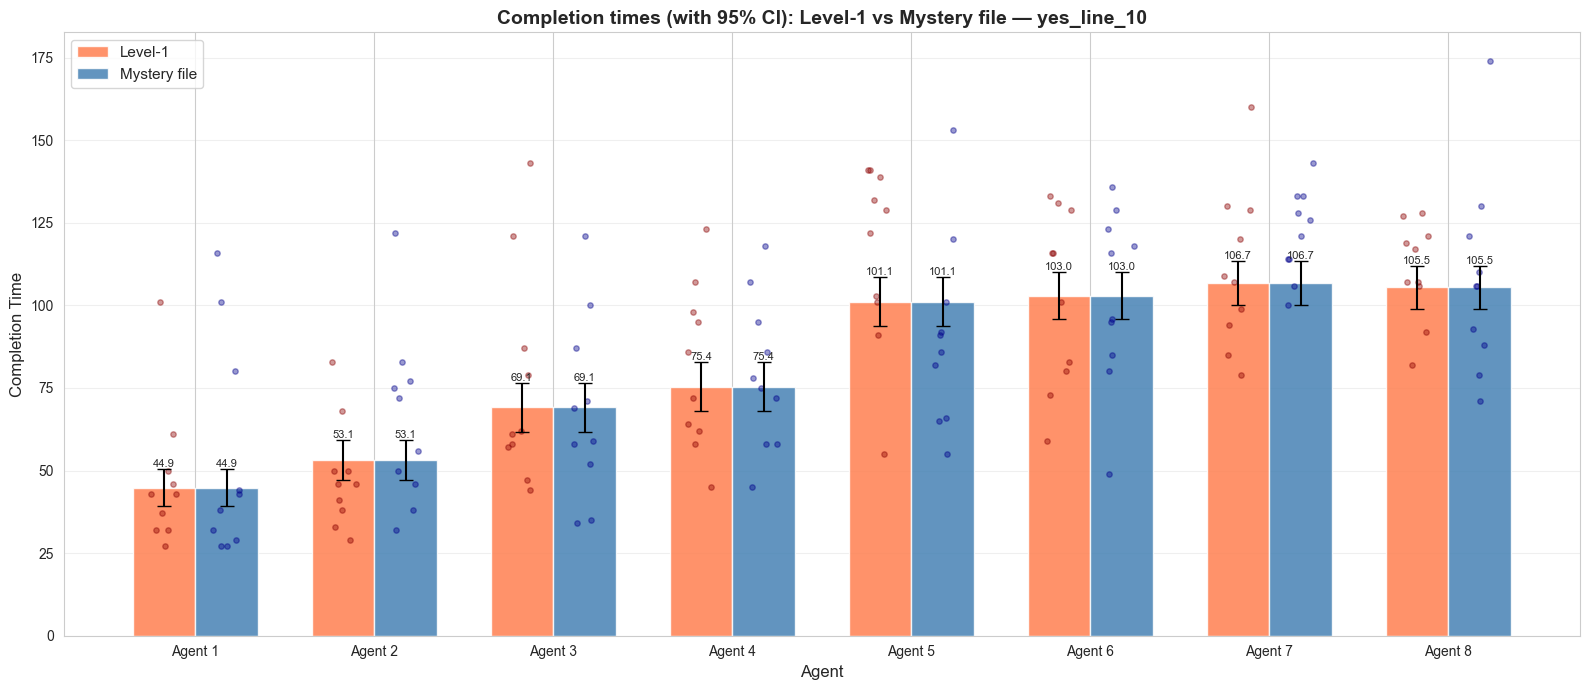

In [9]:
# Dec 2 : figuring out what my mystery file at root of data is (it was a level 0 run for yes_line_10)
fig = compare_two_conditions(
    filepath_cond1='../data/raw-data/level-0/yes_line_10_test.pddl_0.0001_50.csv',
    filepath_cond2='../data/mystery_file.csv',
    cond1_label='Level-1',
    cond2_label='Mystery file',
    title="Completion times (with 95% CI): Level-1 vs Mystery file — yes_line_10",
    #save_path="plots/level1_vs_level0_yes_line_8.png"
)

In [4]:
# -- New function 27-11: super-impose 2 things
def compare_two_conditions(filepath_cond1, filepath_cond2, cond1_label="Condition 1", cond2_label="Condition 2",
                           error="ci", overlay_samples=10, jitter_width=0.08, title=None, save_path=None):
    """
    Compare two conditions (e.g., level-0 vs level-1) side-by-side for each agent.
    
    For each agent: [cond1 bar] [cond2 bar] then next agent
    """
    data1 = load_csv_file(filepath_cond1)
    data2 = load_csv_file(filepath_cond2)
    filename = Path(filepath_cond1).name.split('/')[-1]
    
    summary1 = summarize_runs(data1)
    summary2 = summarize_runs(data2)
    
    n_agents = len(summary1)
    
    # Set up x positions: for each agent, two bars side-by-side
    # Agent 1: x=0, 0.35 | Agent 2: x=1, 1.35 | etc.
    x = np.arange(n_agents)
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Get error bars
    if error == "ci":
        yerr1 = (summary1["ci_high"] - summary1["mean"]).values
        yerr2 = (summary2["ci_high"] - summary2["mean"]).values
        err_label = "95% CI"
    elif error == "sem":
        yerr1 = summary1["sem"].values
        yerr2 = summary2["sem"].values
        err_label = "SEM"
    else:
        yerr1 = summary1["sd"].values
        yerr2 = summary2["sd"].values
        err_label = "SD"
    
    means1 = summary1["mean"].values
    means2 = summary2["mean"].values
    
    # Plot bars
    bars1 = ax.bar(x - width/2, means1, width, yerr=yerr1, capsize=5, 
                   label=cond1_label, alpha=0.85, color="coral", ecolor="black")
    bars2 = ax.bar(x + width/2, means2, width, yerr=yerr2, capsize=5, 
                   label=cond2_label, alpha=0.85, color="steelblue", ecolor="black")
    
    # Overlay sample points
    if overlay_samples and overlay_samples > 0:
        rng = np.random.default_rng(42)
        
        # Condition 1 points
        for j, agent in enumerate(data1.columns):
            vals = data1[agent].values
            take = min(overlay_samples, len(vals))
            idxs = rng.choice(len(vals), size=take, replace=False)
            xs = (j - width/2) + rng.uniform(-jitter_width, jitter_width, size=take)
            ax.scatter(xs, vals[idxs], s=15, alpha=0.4, color="darkred")
        
        # Condition 2 points
        for j, agent in enumerate(data2.columns):
            vals = data2[agent].values
            take = min(overlay_samples, len(vals))
            idxs = rng.choice(len(vals), size=take, replace=False)
            xs = (j + width/2) + rng.uniform(-jitter_width, jitter_width, size=take)
            ax.scatter(xs, vals[idxs], s=15, alpha=0.4, color="darkblue")
    
    # Labels on bars
    for bar, mu, err in zip(bars1, means1, yerr1):
        ax.text(bar.get_x()+bar.get_width()/2., mu + err, f"{mu:.1f}",
                ha="center", va="bottom", fontsize=8)
    for bar, mu, err in zip(bars2, means2, yerr2):
        ax.text(bar.get_x()+bar.get_width()/2., mu + err, f"{mu:.1f}",
                ha="center", va="bottom", fontsize=8)
    
    if title is None:
        title = f"Completion times ± {err_label} — {filename}"
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Agent", fontsize=12)
    ax.set_ylabel("Completion Time", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Agent {i+1}" for i in range(n_agents)])
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    return fig

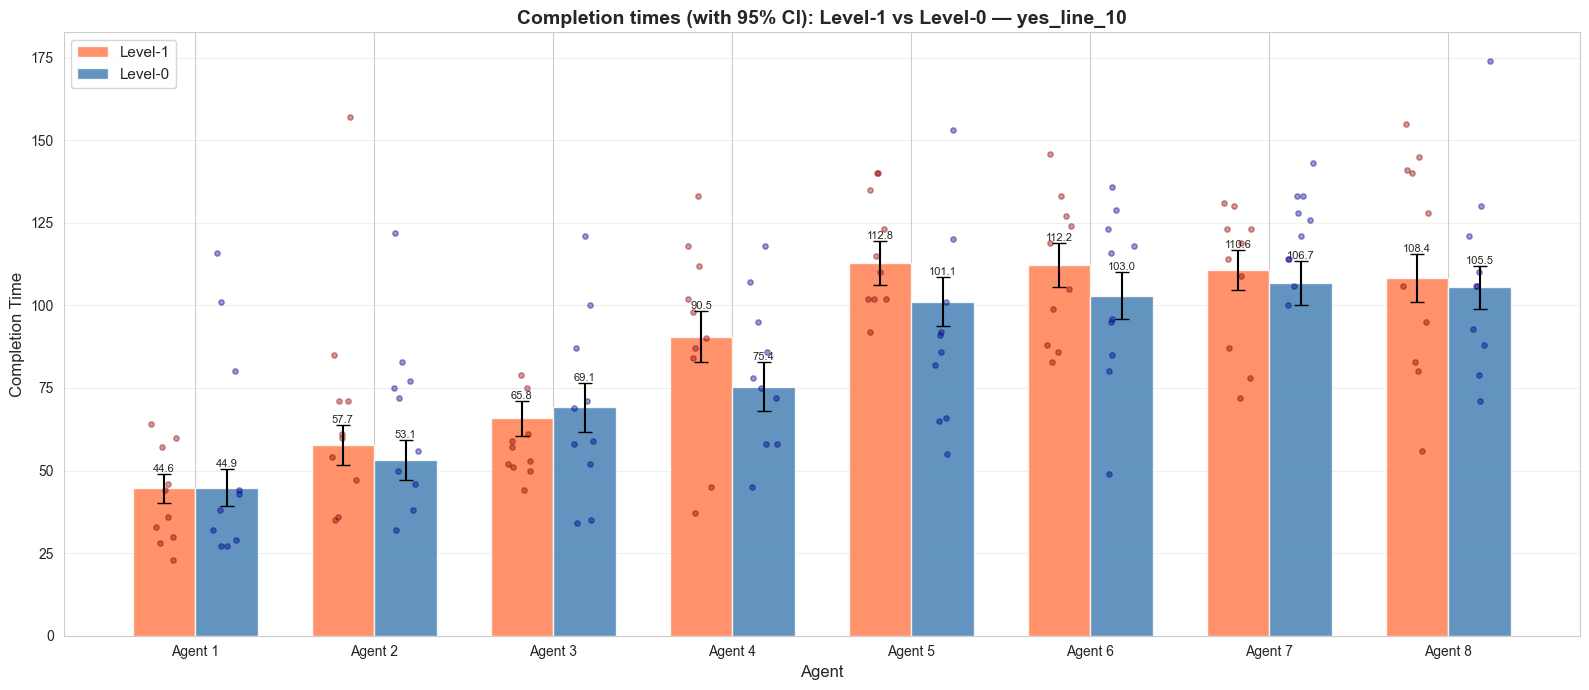

In [5]:
fig = compare_two_conditions(
    filepath_cond1='../data/raw-data/level-1/yes_line_10_test.pddl_0.0001_50.csv',
    filepath_cond2='../data/raw-data/level-0/yes_line_10_test.pddl_0.0001_50.csv',
    cond1_label='Level-1',
    cond2_label='Level-0',
    title="Completion times (with 95% CI): Level-1 vs Level-0 — yes_line_10",
    #save_path="plots/level1_vs_level0_yes_line_8.png"
)

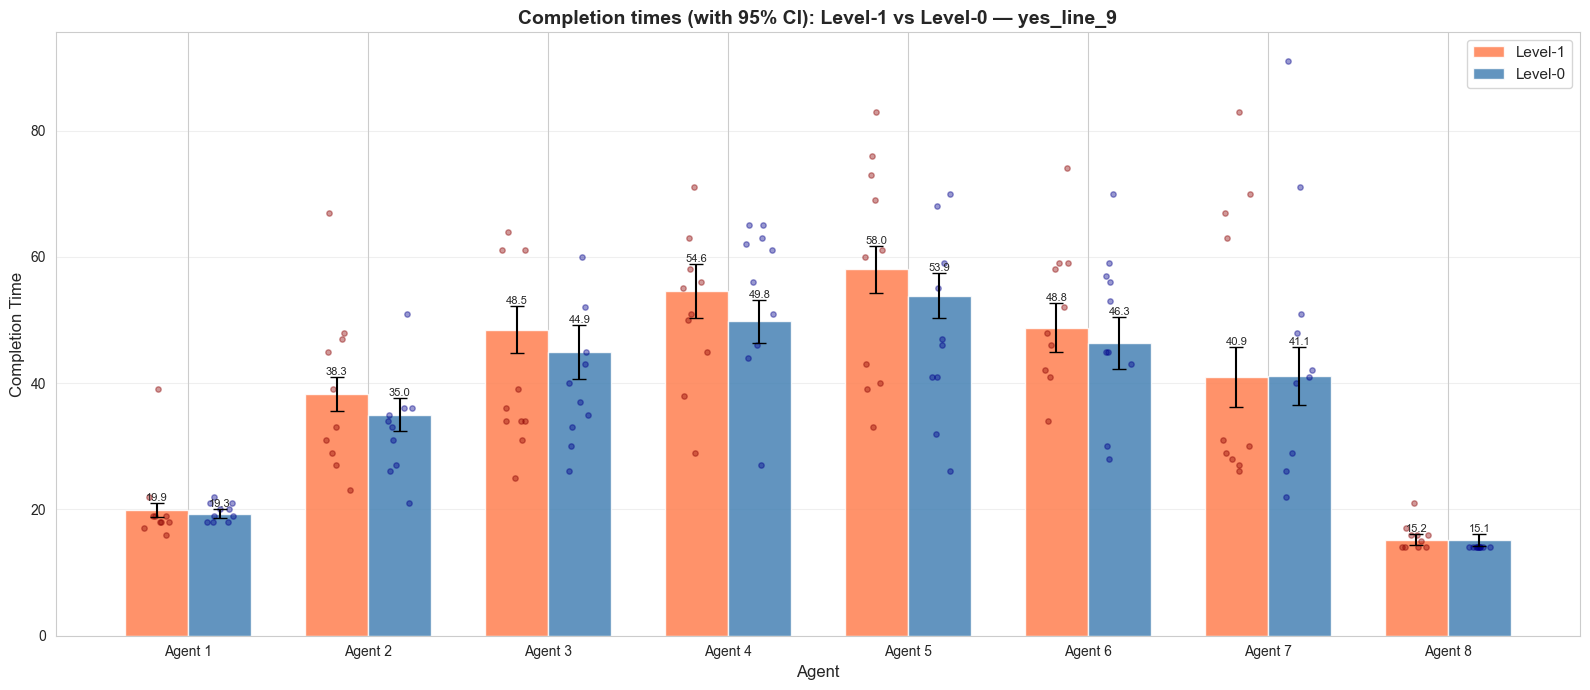

In [77]:
fig = compare_two_conditions(
    filepath_cond1='../data/raw-data/level-1/yes_line_9_test.pddl_0.0001_50.csv',
    filepath_cond2='../data/raw-data/level-0/yes_line_9_test.pddl_0.0001_50.csv',
    cond1_label='Level-1',
    cond2_label='Level-0',
    title="Completion times (with 95% CI): Level-1 vs Level-0 — yes_line_9",
    save_path="plots/level1_vs_level0_yes_line_9.png"
)

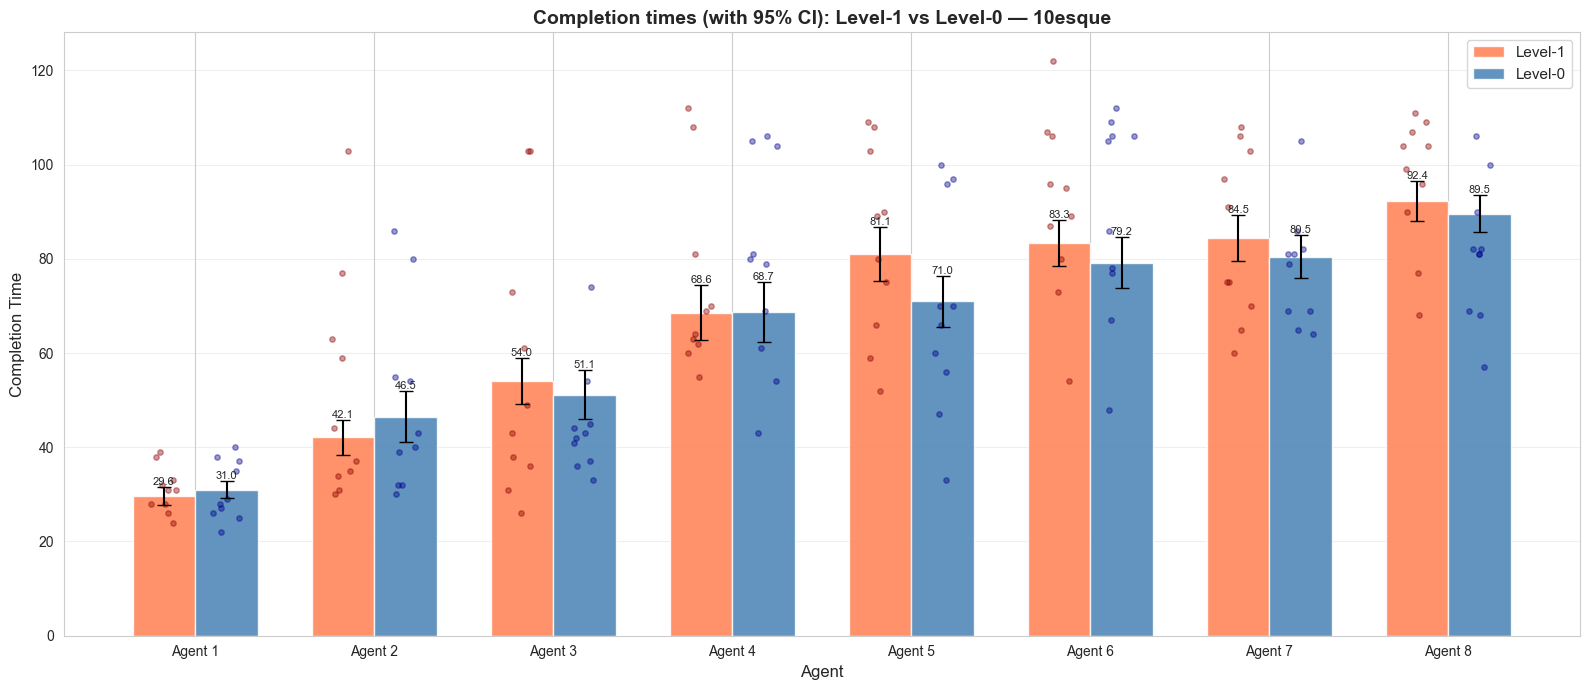

In [85]:
fig = compare_two_conditions(
    filepath_cond1='../data/raw-data/level-1/10esque_test.pddl_0.0001_50.csv',
    filepath_cond2='../data/raw-data/level-0/10esque_test.pddl_0.0001_50.csv',
    cond1_label='Level-1',
    cond2_label='Level-0',
    title="Completion times (with 95% CI): Level-1 vs Level-0 — 10esque",
    save_path="plots/level1_vs_level0_10esque.png"
)

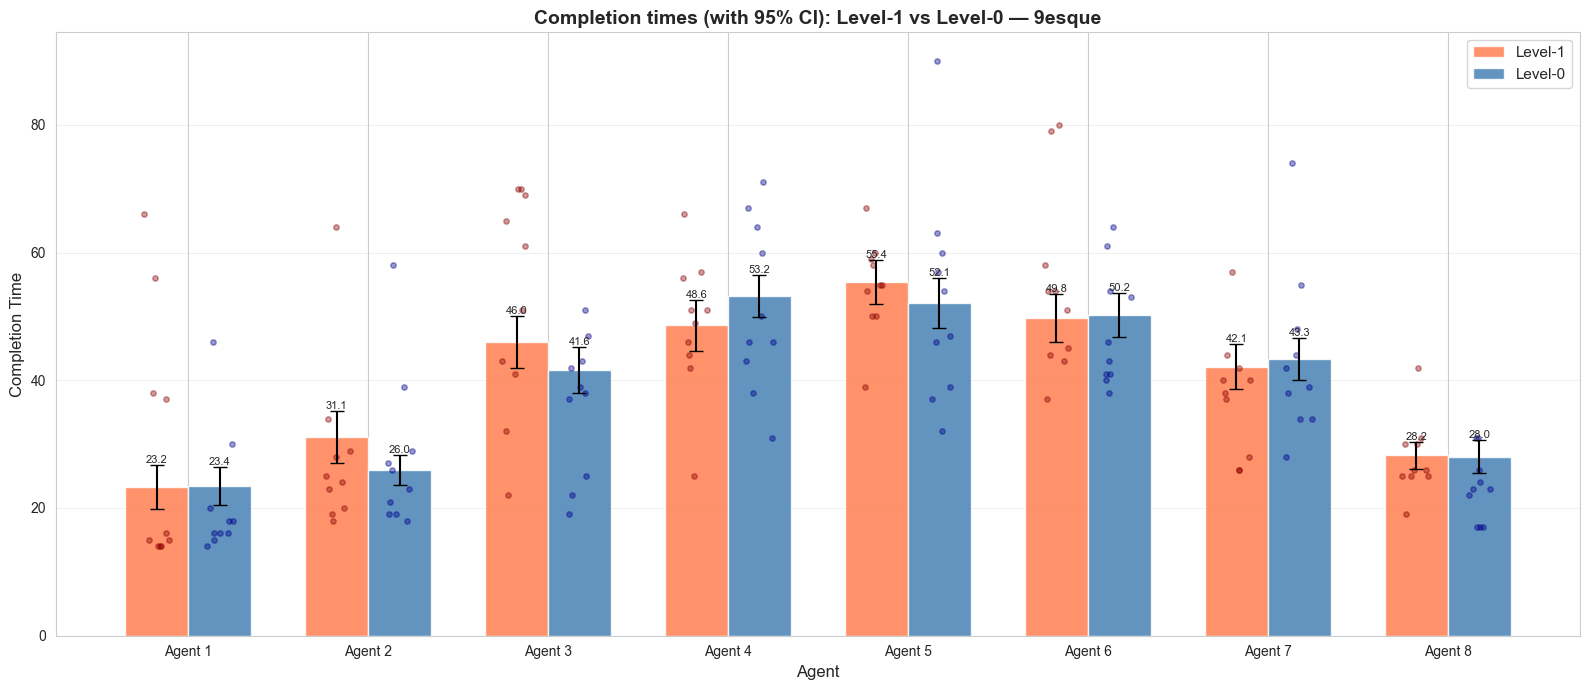

In [80]:
fig = compare_two_conditions(
    filepath_cond1='../data/raw-data/level-1/9esque_test.pddl_0.0001_50.csv',
    filepath_cond2='../data/raw-data/level-0/9esque_test.pddl_0.0001_50.csv',
    cond1_label='Level-1',
    cond2_label='Level-0',
    title="Completion times (with 95% CI): Level-1 vs Level-0 — 9esque",
    save_path="plots/level1_vs_level0_9esque9esque.png"
)

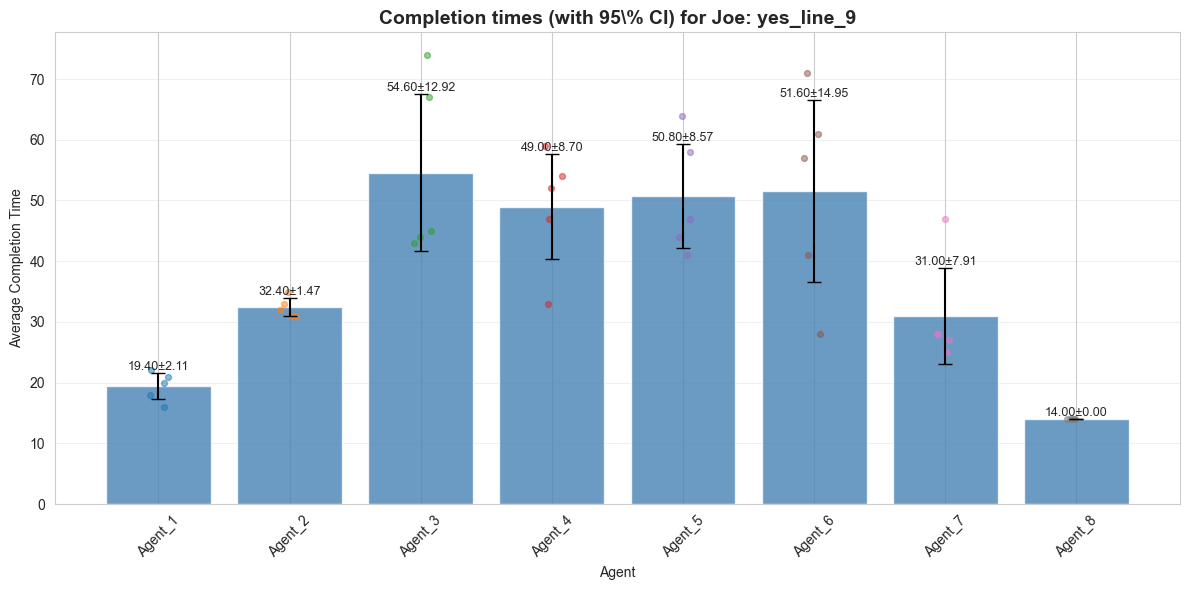

In [83]:
glop = plot_single_file('../data/raw-data/paper_data/yes_line_9_test.pddl_0.0001.csv', title="Completion times (with 95\% CI) for Joe: yes_line_9")

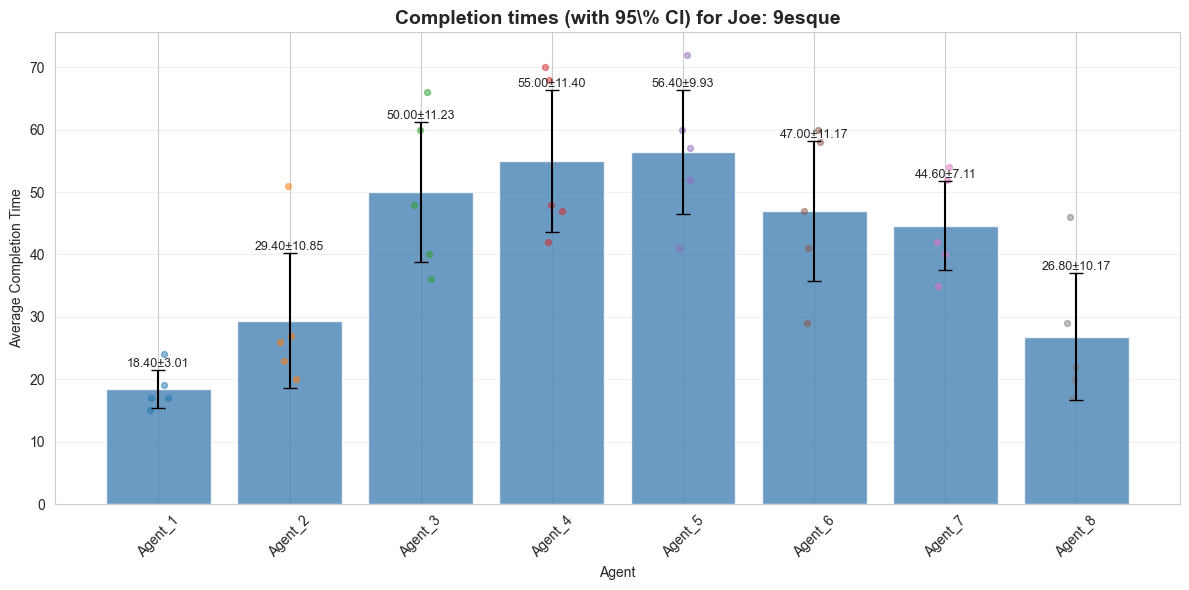

In [84]:
glop = plot_single_file('../data/raw-data/paper_data/9esque_test.pddl_0.0001.csv', title="Completion times (with 95\% CI) for Joe: 9esque")

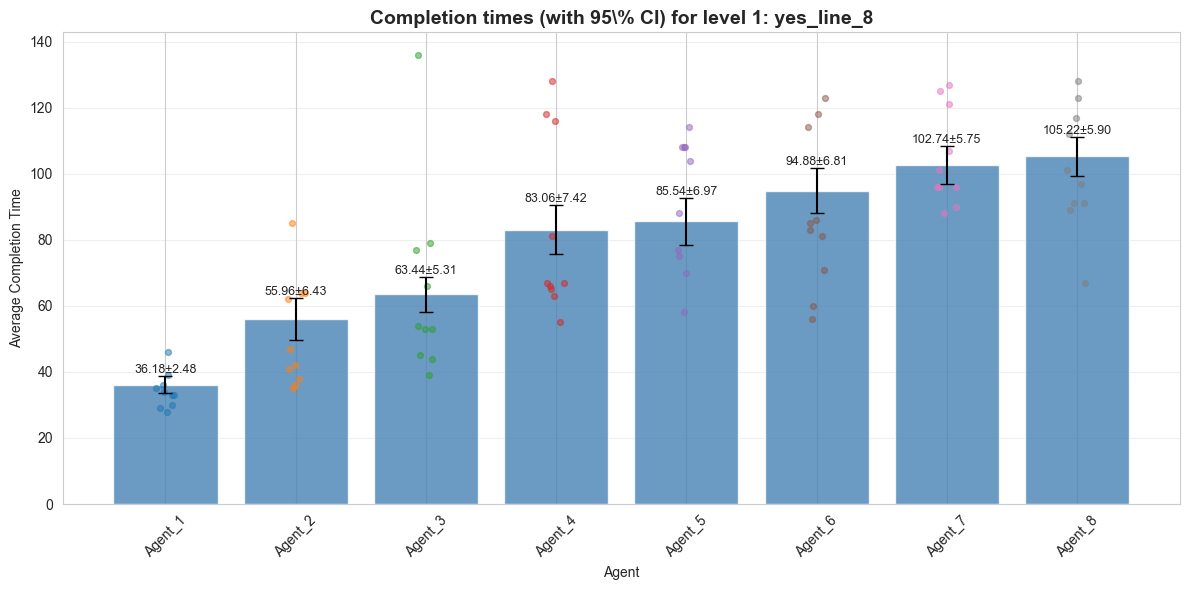

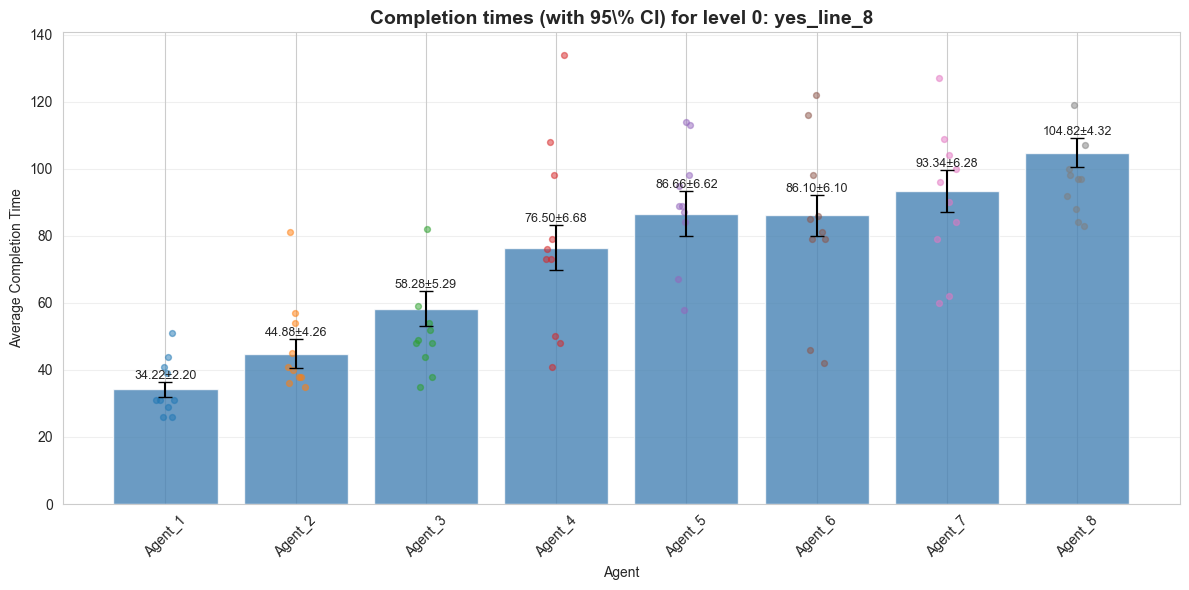

In [63]:
nol1_lvl1 = plot_single_file('../data/raw-data/level-1/yes_line_8_test.pddl_0.0001_50.csv', title="Completion times (with 95\% CI) for level 1: yes_line_8")

nol1_lvl0 = plot_single_file('../data/raw-data/level-0/yes_line_8_test.pddl_0.0001_50.csv', title="Completion times (with 95\% CI) for level 0: yes_line_8")

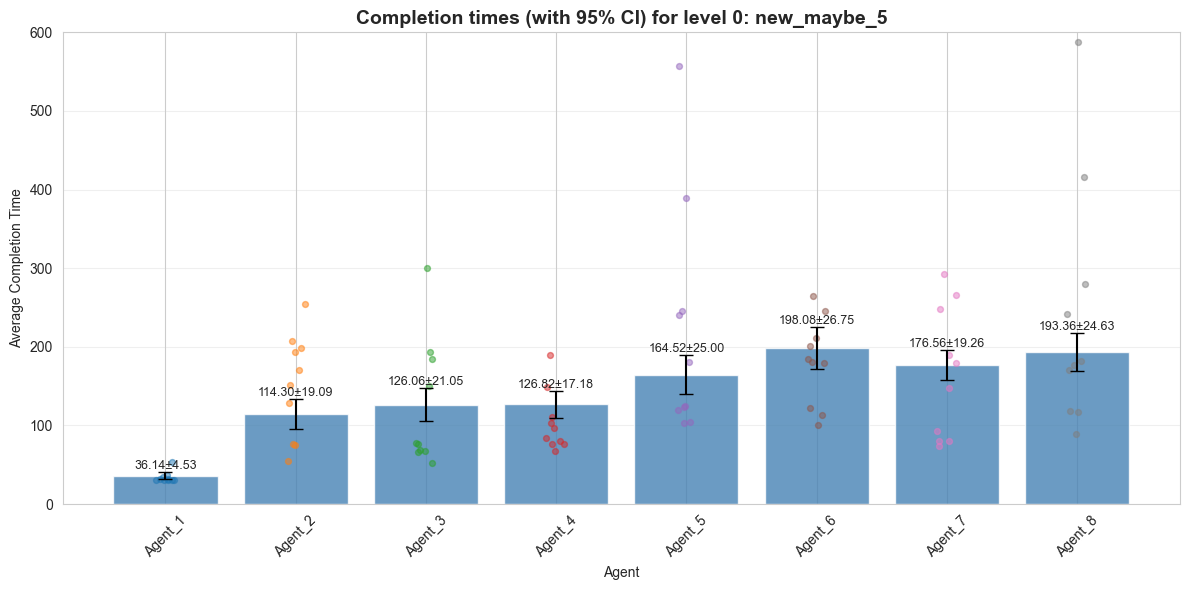

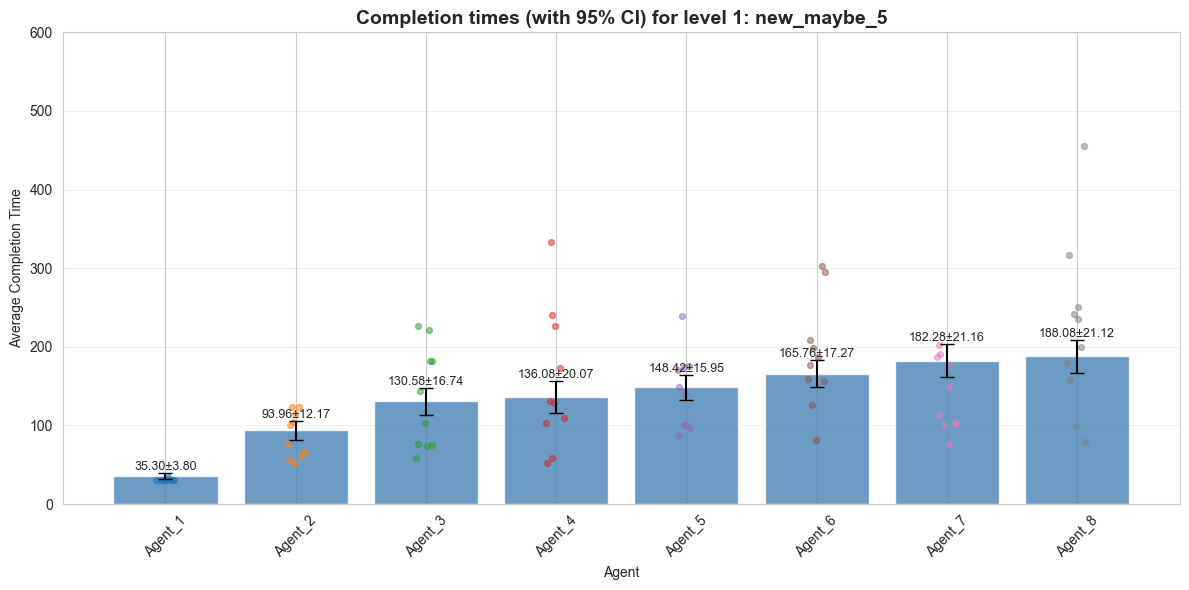

In [48]:
# Maps with big diff on univ and inequality btw my level 1 and my level --- 1) new maybe 5

nm5_lvl0 = plot_single_file('../data/raw-data/level-0/new_maybe_5.pddl_0.0001_50.csv', title="Completion times (with 95% CI) for level 0: new_maybe_5")
nm5_lvl0.axes[0].set_ylim(0,600)

nm5_lvl0.savefig('plots/completion_times_new_maybe_5_lvl0.png', dpi=300, bbox_inches='tight')

plt.show()

nm5_lvl1 = plot_single_file('../data/raw-data/level-1/new_maybe_5.pddl_0.0001_50.csv', title="Completion times (with 95% CI) for level 1: new_maybe_5")
nm5_lvl1.axes[0].set_ylim(0,600)

nm5_lvl1.savefig('plots/completion_times_new_maybe_5_lvl1.png', dpi=300, bbox_inches='tight')

plt.show()

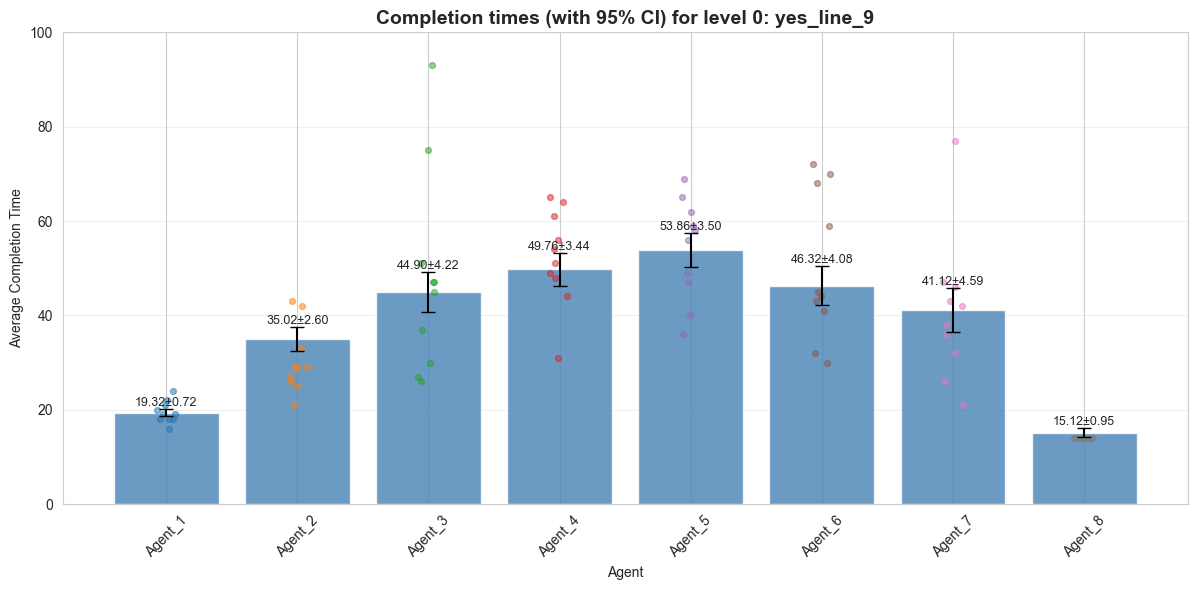

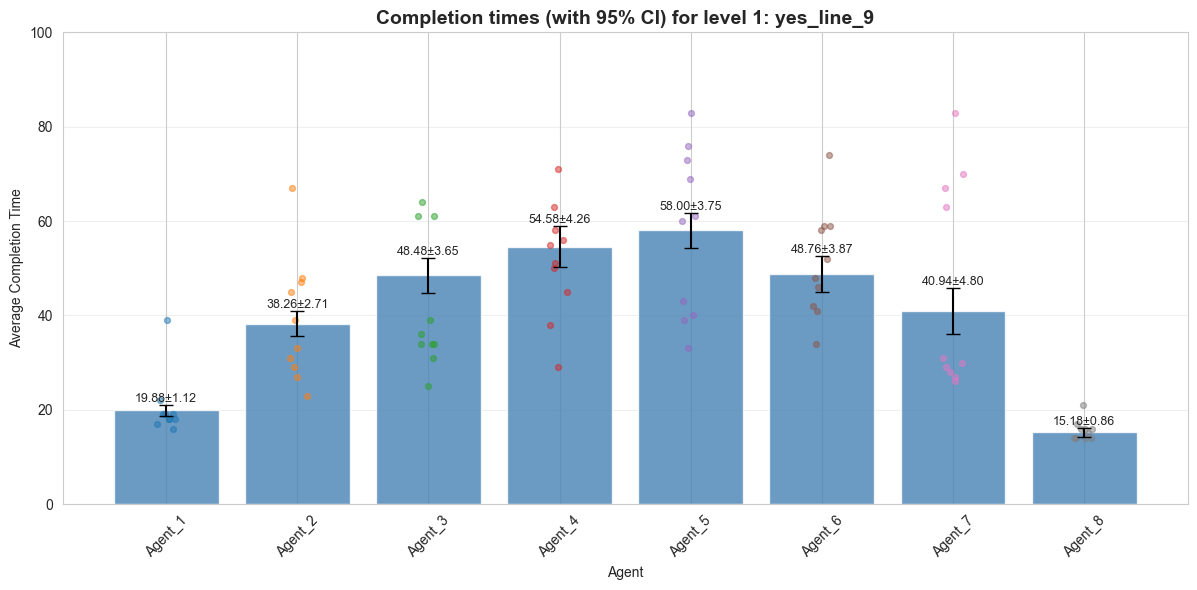

In [52]:
# Maps with big diff on univ and inequality btw my level 1 and my level --- 2) yes_line_9

y9_lvl0 = plot_single_file('../data/raw-data/level-0/yes_line_9_test.pddl_0.0001_50.csv', 
                           title="Completion times (with 95% CI) for level 0: yes_line_9")
y9_lvl0.axes[0].set_ylim(0,100)

y9_lvl0.savefig('plots/completion_times_yes_line_9_lvl0.png', dpi=300, bbox_inches='tight')

plt.show()

y9_lvl1 = plot_single_file('../data/raw-data/level-1/yes_line_9_test.pddl_0.0001_50.csv', 
                           title="Completion times (with 95% CI) for level 1: yes_line_9")
y9_lvl1.axes[0].set_ylim(0,100)

y9_lvl1.savefig('plots/completion_times_yes_line_9_lvl1.png', dpi=300, bbox_inches='tight')

plt.show()

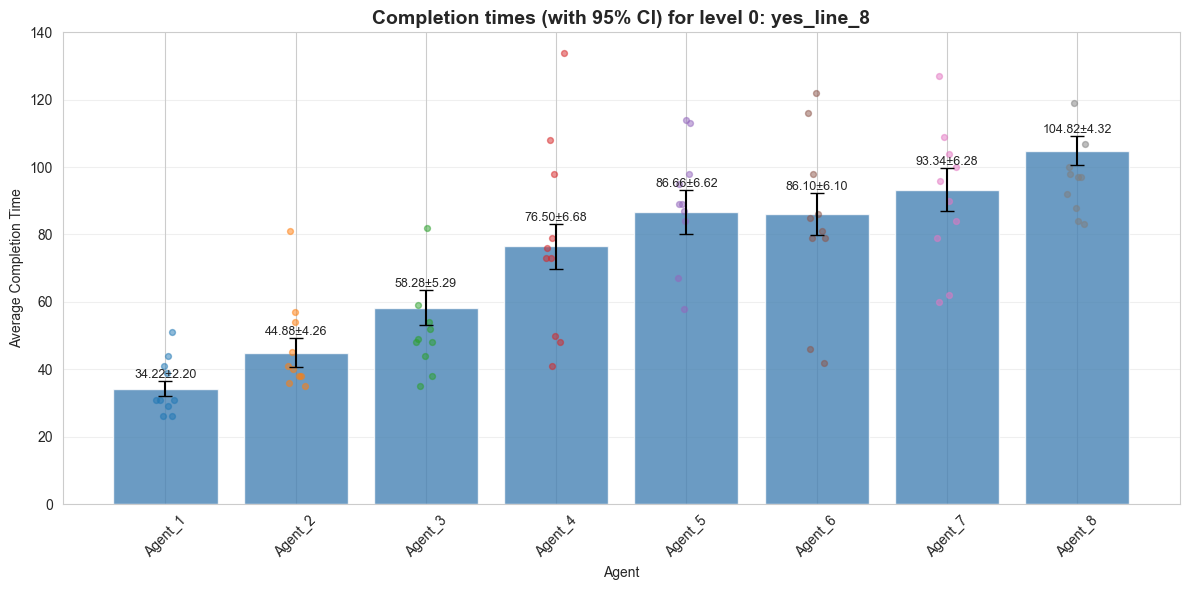

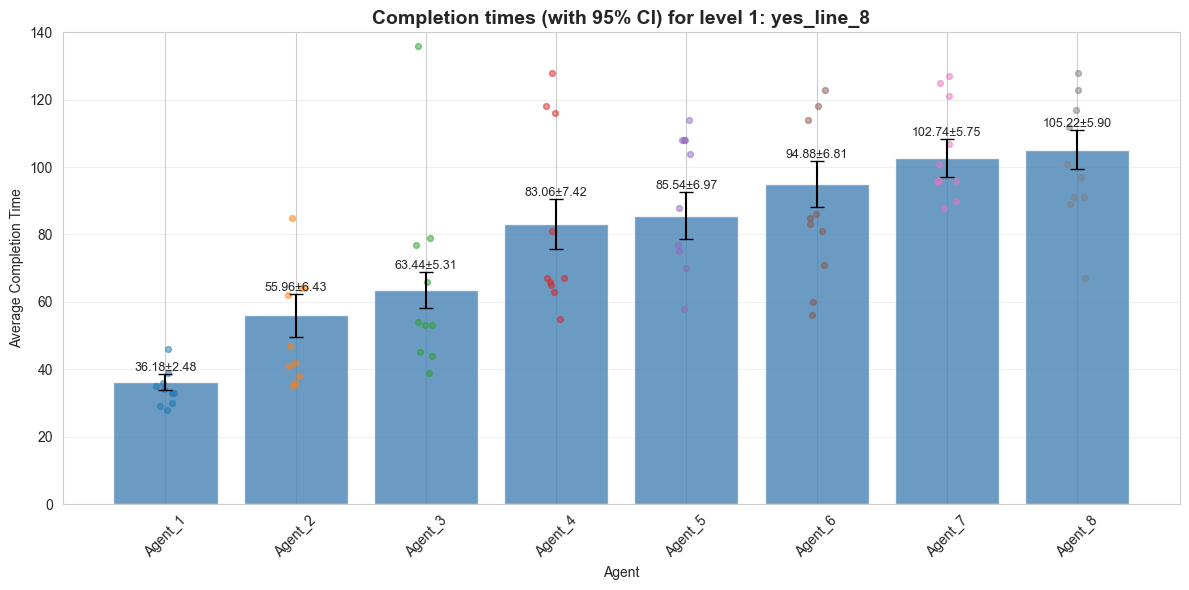

In [56]:
# Maps with big diff on univ btw my level 1 and my level --- 3 yes_line_8

y8_lvl0 = plot_single_file('../data/raw-data/level-0/yes_line_8_test.pddl_0.0001_50.csv', 
                           title="Completion times (with 95% CI) for level 0: yes_line_8")
y8_lvl0.axes[0].set_ylim(0,140)

y8_lvl0.savefig('plots/completion_times_yes_line_8_lvl0.png', dpi=300, bbox_inches='tight')

plt.show()

y8_lvl1 = plot_single_file('../data/raw-data/level-1/yes_line_8_test.pddl_0.0001_50.csv', 
                           title="Completion times (with 95% CI) for level 1: yes_line_8")
y8_lvl1.axes[0].set_ylim(0,140)

y8_lvl1.savefig('plots/completion_times_yes_line_8_lvl1.png', dpi=300, bbox_inches='tight')

plt.show()

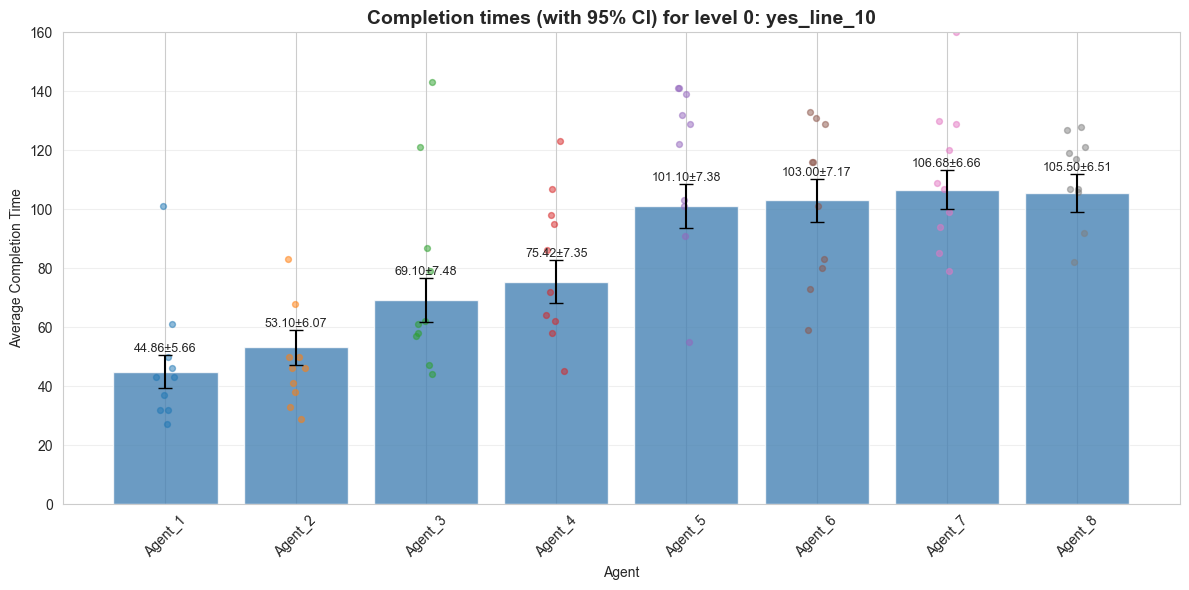

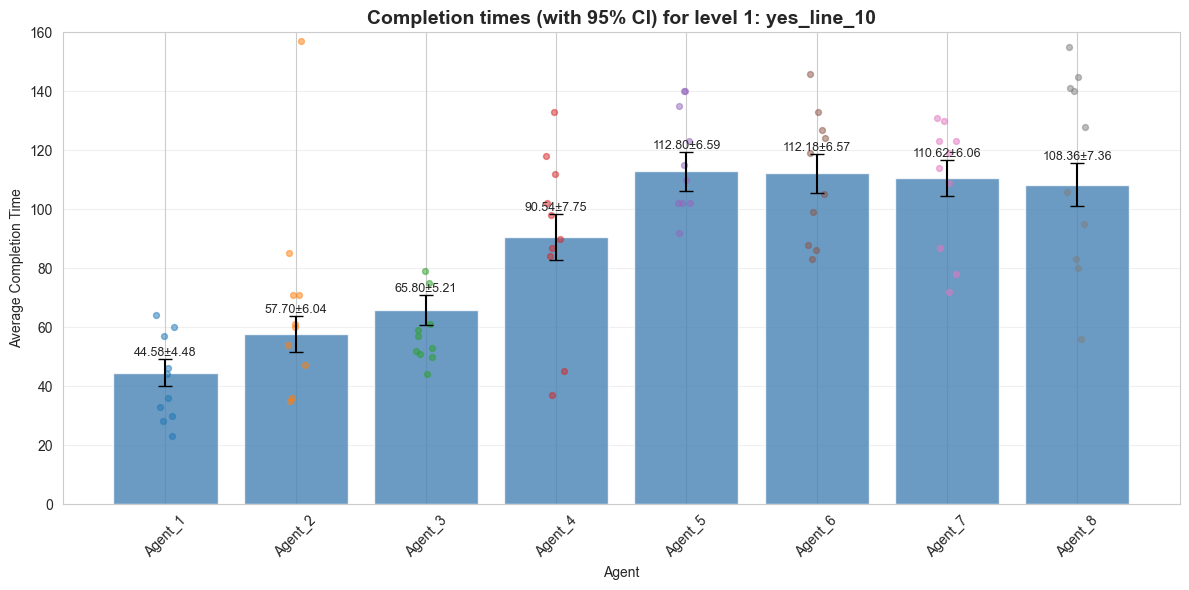

In [60]:
# Maps with big diff on univ btw my level 1 and my level --- 4 yes_line_10

y10_lvl0 = plot_single_file('../data/raw-data/level-0/yes_line_10_test.pddl_0.0001_50.csv', 
                           title="Completion times (with 95% CI) for level 0: yes_line_10")
y10_lvl0.axes[0].set_ylim(0,160)

y10_lvl0.savefig('plots/completion_times_yes_line_10_lvl0.png', dpi=300, bbox_inches='tight')

plt.show()

y10_lvl1 = plot_single_file('../data/raw-data/level-1/yes_line_10_test.pddl_0.0001_50.csv', 
                           title="Completion times (with 95% CI) for level 1: yes_line_10")
y10_lvl1.axes[0].set_ylim(0,160)

y10_lvl1.savefig('plots/completion_times_yes_line_10_lvl1.png', dpi=300, bbox_inches='tight')

plt.show()

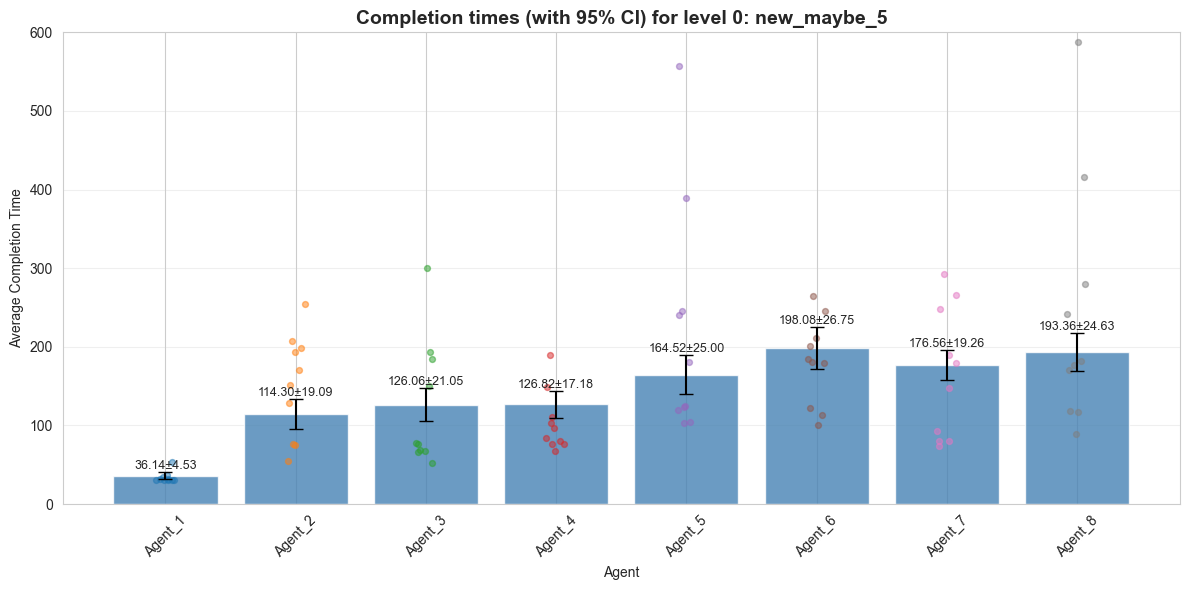

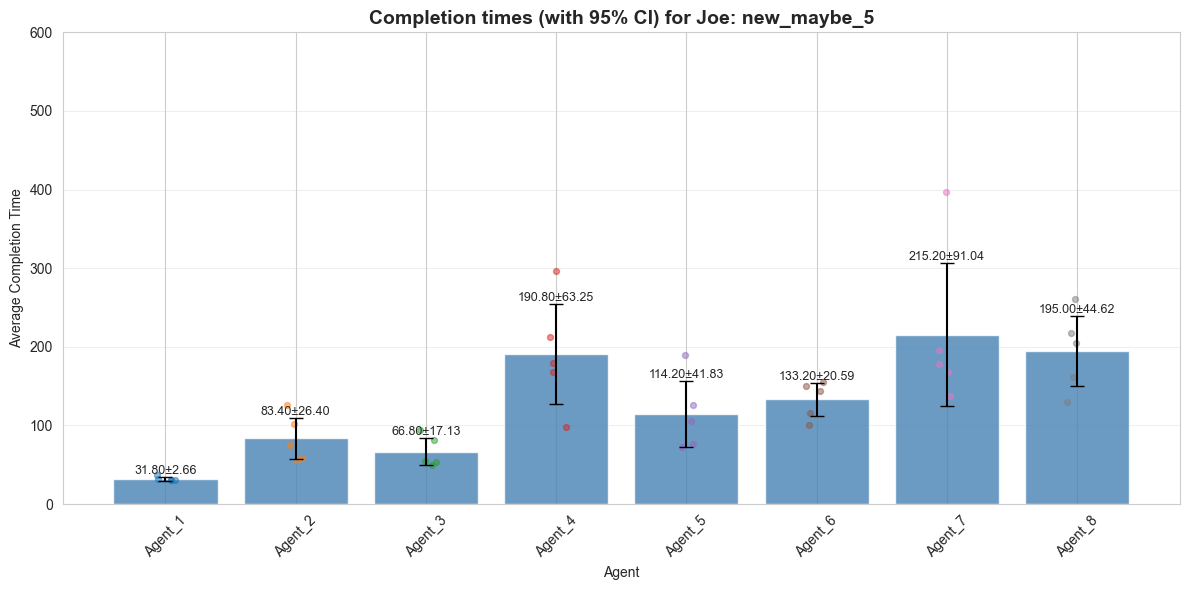

In [41]:
# Map with biggest diff on univ btw my level 0 and Joe's run (new_maybe_5)
nol1_lvl0 = plot_single_file('../data/raw-data/level-0/new_maybe_5.pddl_0.0001_50.csv', 
                             title="Completion times (with 95% CI) for level 0: new_maybe_5")
nol1_lvl0.axes[0].set_ylim(0,600)

nol1_lvl0.savefig('plots/completion_times_new_maybe_5_lvl0.png', dpi=300, bbox_inches='tight')

plt.show()
nol1_joe = plot_single_file('../data/raw-data/paper_data/new_maybe_5.pddl_0.0001.csv', 
                            title="Completion times (with 95% CI) for Joe: new_maybe_5")
nol1_joe.axes[0].set_ylim(0,600)

nol1_joe.savefig('plots/completion_times_new_maybe_5_joe.png', dpi=300, bbox_inches='tight')
plt.show()

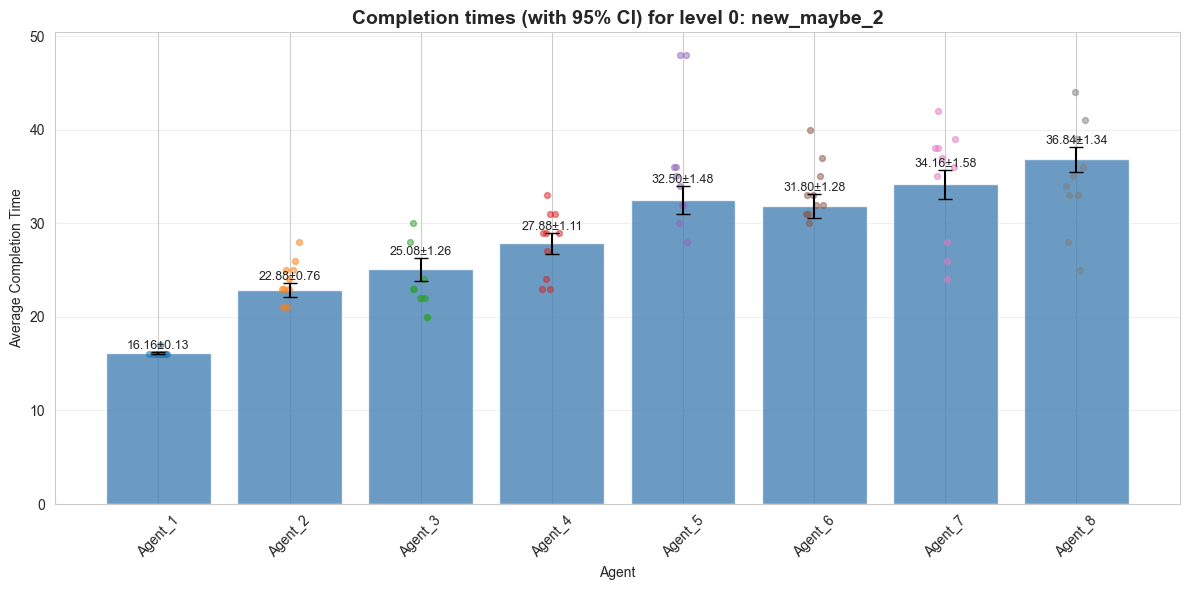

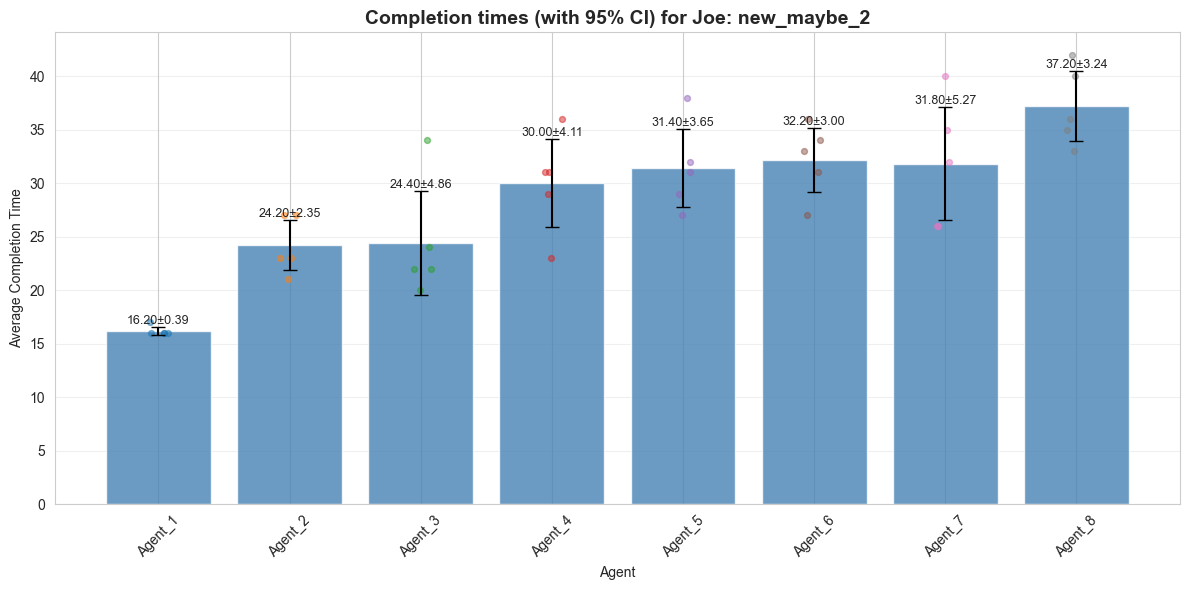

In [29]:
# Map with smallest diff on univ btw my level 0 and Joe's run (new_maybe_2)
nol1_lvl0 = plot_single_file('../data/raw-data/level-0/new_maybe_2.pddl_0.0001_50.csv', 
                             title="Completion times (with 95% CI) for level 0: new_maybe_2")
nol1_lvl0.axes[0].set_ylim(0,50)

nol1_lvl0.savefig('plots/completion_times_new_maybe_2_lvl0.png', dpi=300, bbox_inches='tight')

nol1_joe = plot_single_file('../data/raw-data/paper_data/new_maybe_2.pddl_0.0001.csv', 
                            title="Completion times (with 95% CI) for Joe: new_maybe_2")
nol1_joe.axes[0].set_ylim(0,50)

nol1_joe.savefig('plots/completion_times_new_maybe_2_joe.png', dpi=300, bbox_inches='tight')

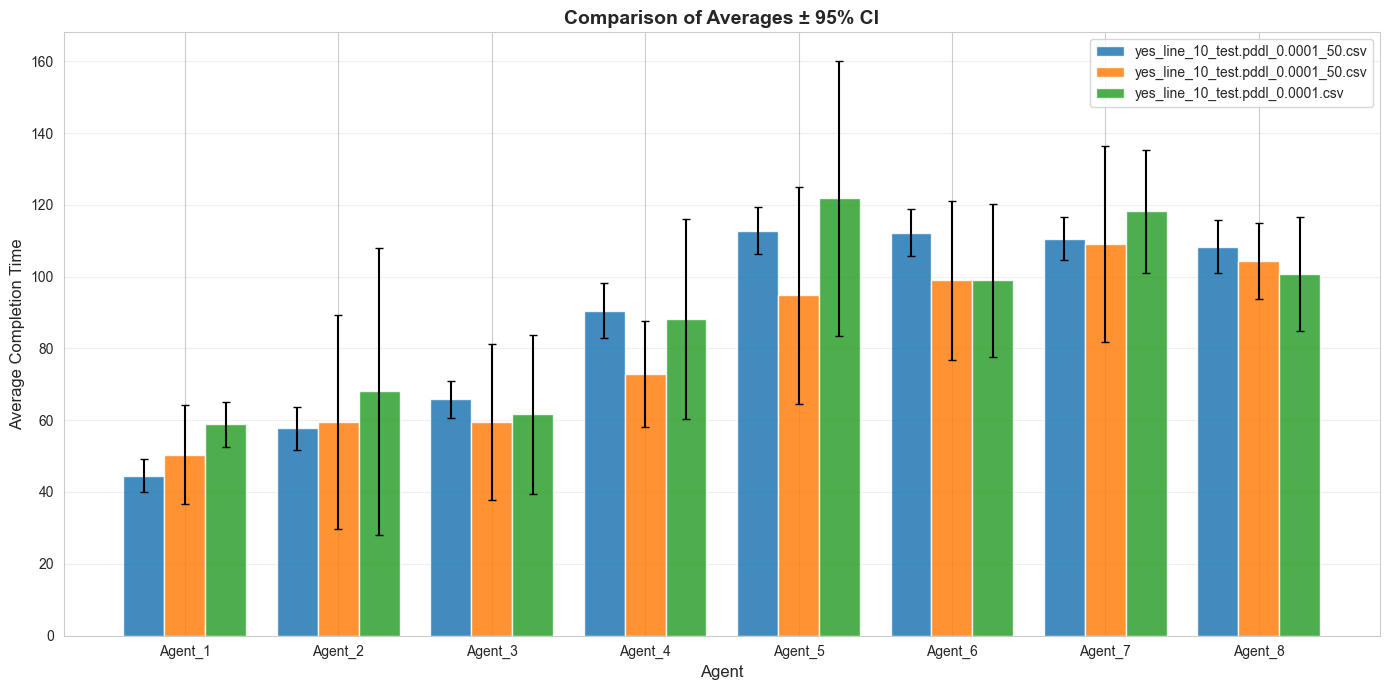

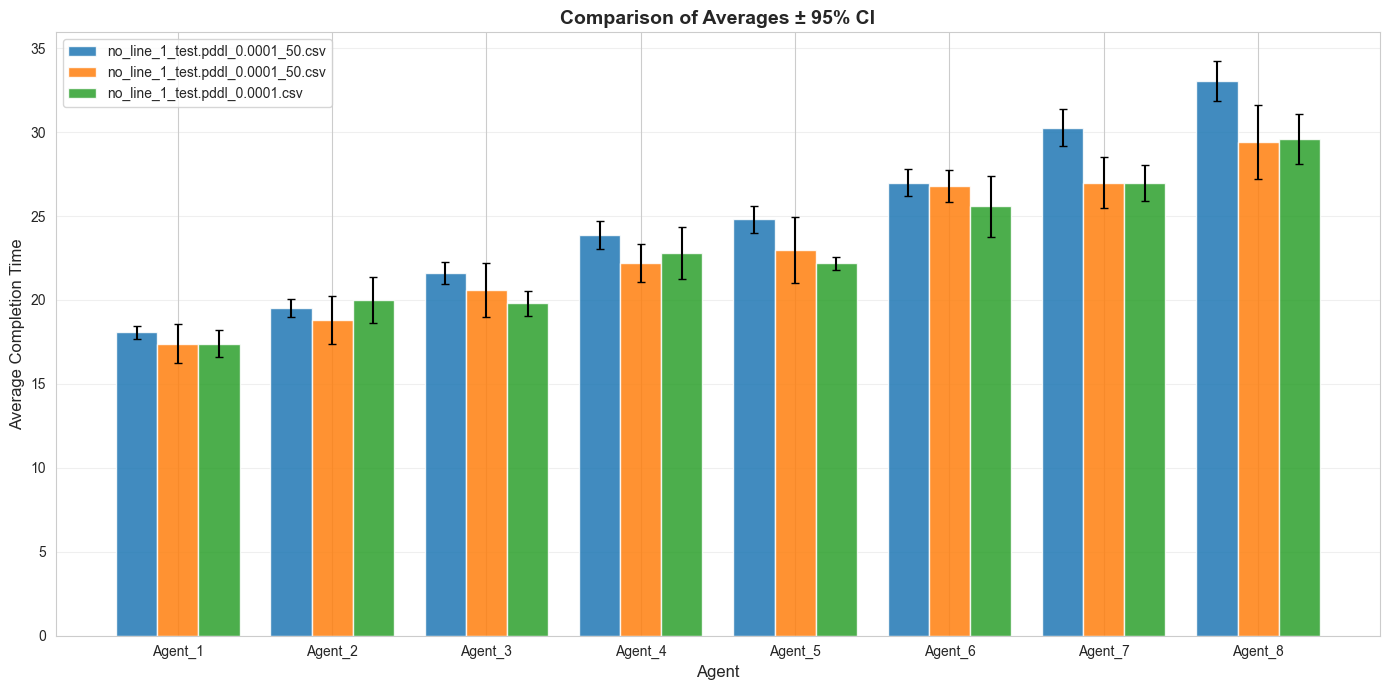

In [4]:
# Compare level-1 and level-0 results with original paper data

compare_files([
     'level-1/yes_line_10_test.pddl_0.0001_50.csv',
     'level-0/yes_line_10_test.pddl_0.0001_50.csv',
     '../paper_data/yes_line_10_test.pddl_0.0001.csv'
 ])
#compare_files([
#    'level-1/maybe_6.pddl_0.0001_50.csv',
 #    'level-0/maybe_6.pddl_0.0001_50.csv',
#     '../paper_data/maybe_6.pddl_0.0001.csv'
# ])
compare_files([
     'level-1/no_line_1_test.pddl_0.0001_50.csv',
     'level-0/no_line_1_test.pddl_0.0001_50.csv',
     '../paper_data/no_line_1_test.pddl_0.0001.csv'
 ])

In [ ]:
compare_files([
     'level-1/yes_line_A.pddl_0.0001_50.csv',
     'level-0/yes_line_A.pddl_0.0001_50.csv',
     '../paper_data/yes_line_A.pddl_0.0001.csv'
 ])

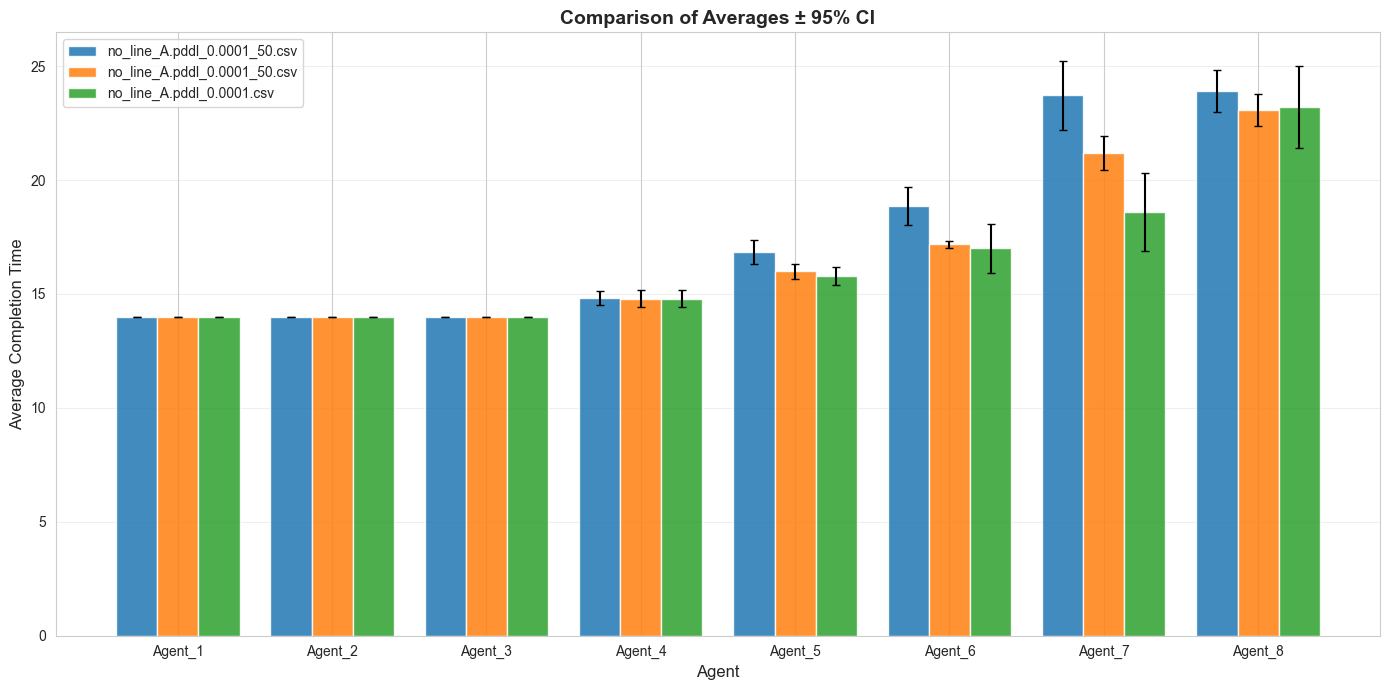

In [13]:
compare_files([
     'level-1/no_line_A.pddl_0.0001_50.csv',
     'level-0/no_line_A.pddl_0.0001_50.csv',
     '../paper_data/no_line_A.pddl_0.0001.csv'
 ])

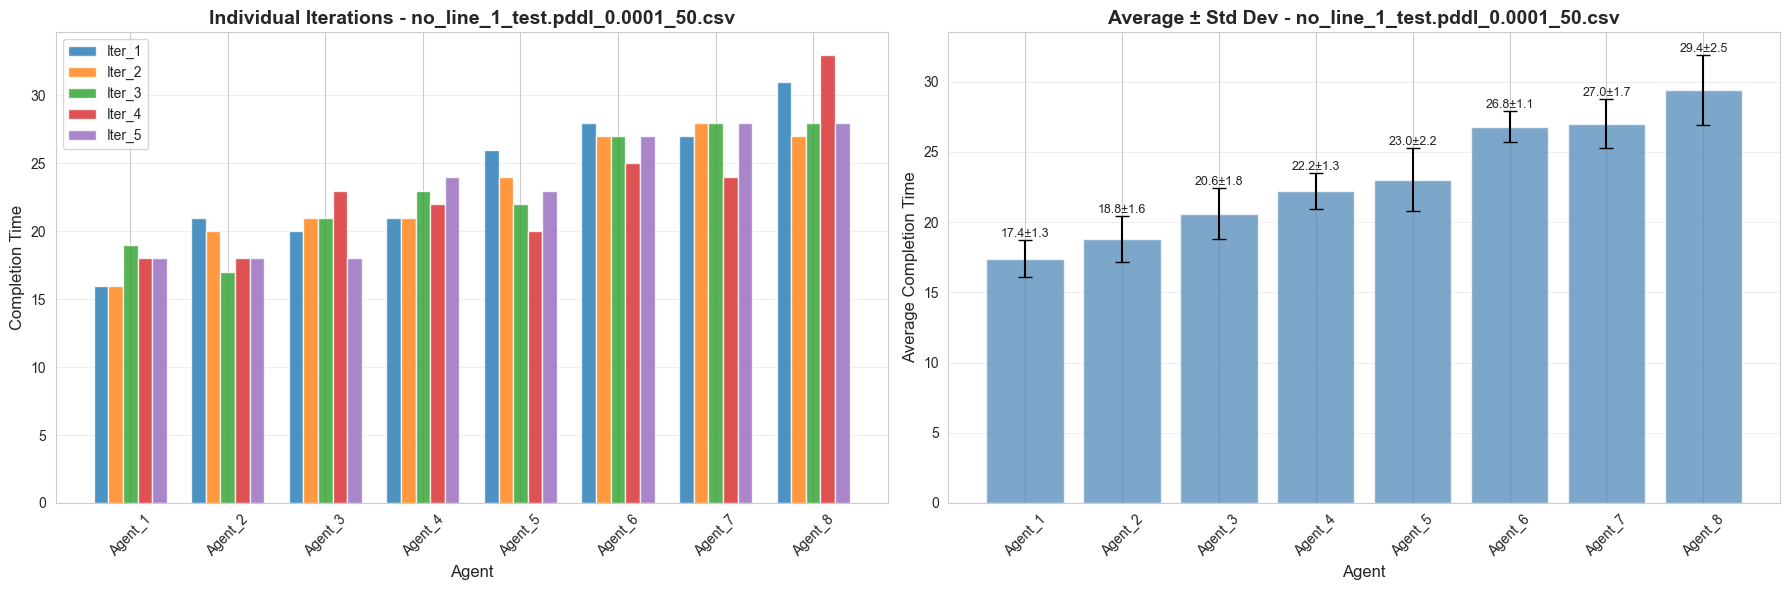

/var/folders/01/trt9pc8d2rn32k90mtrrhlbw0000gq/T/ipykernel_71465/359683101.py:95: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


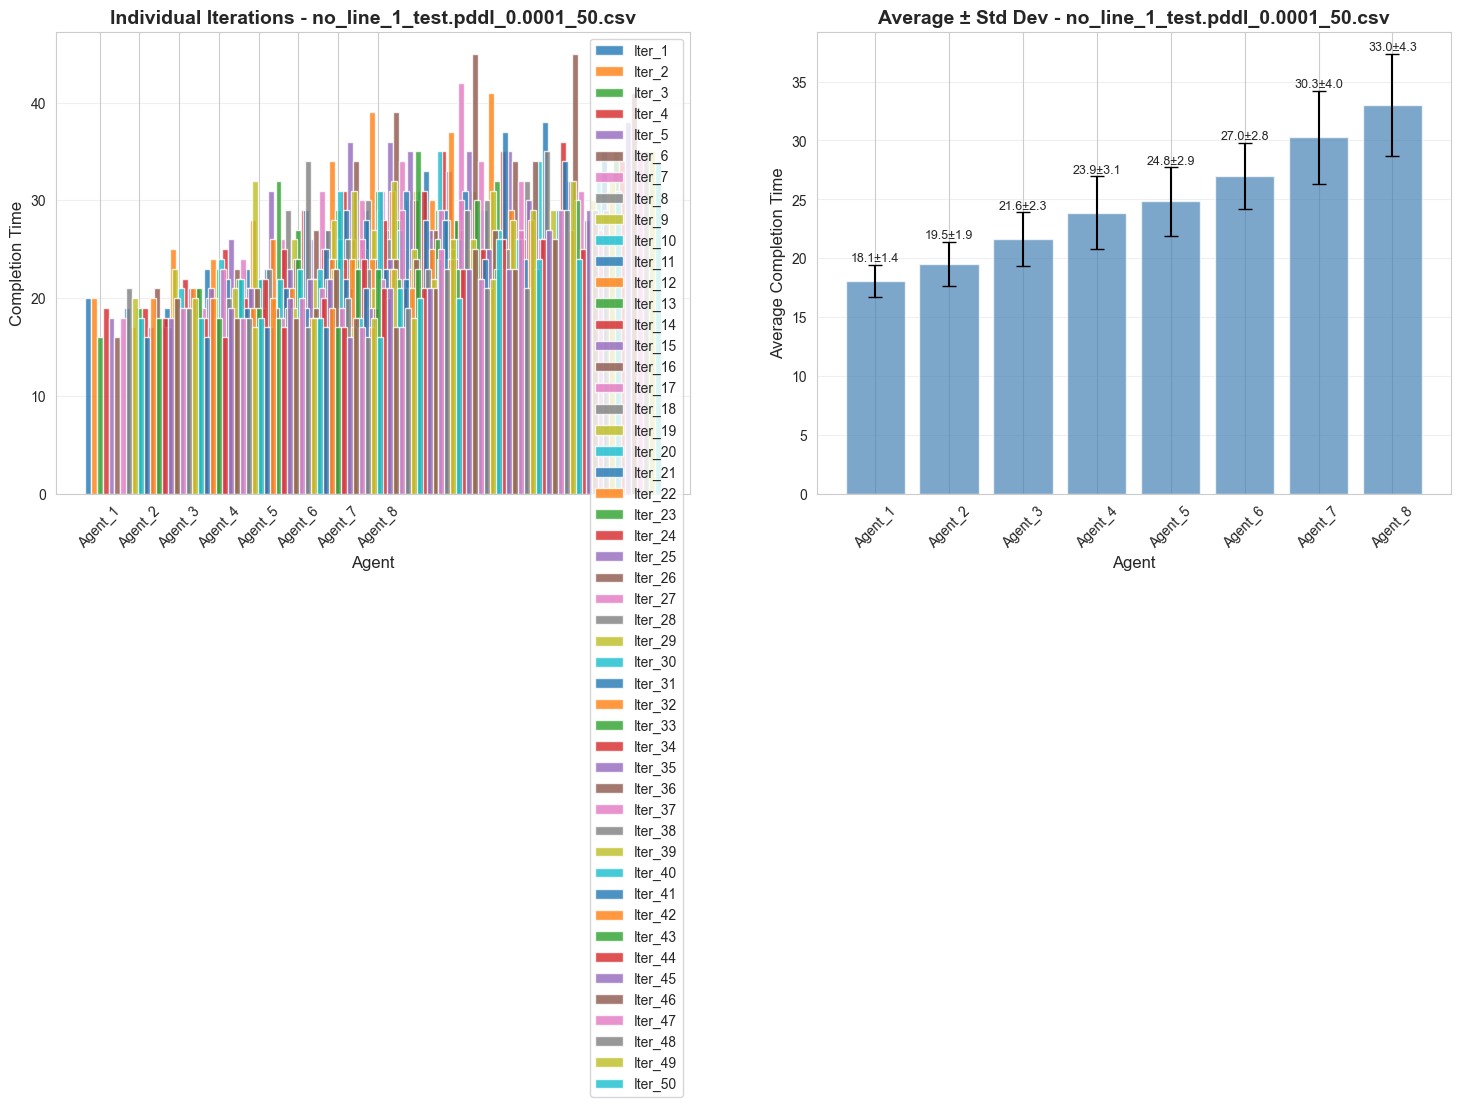

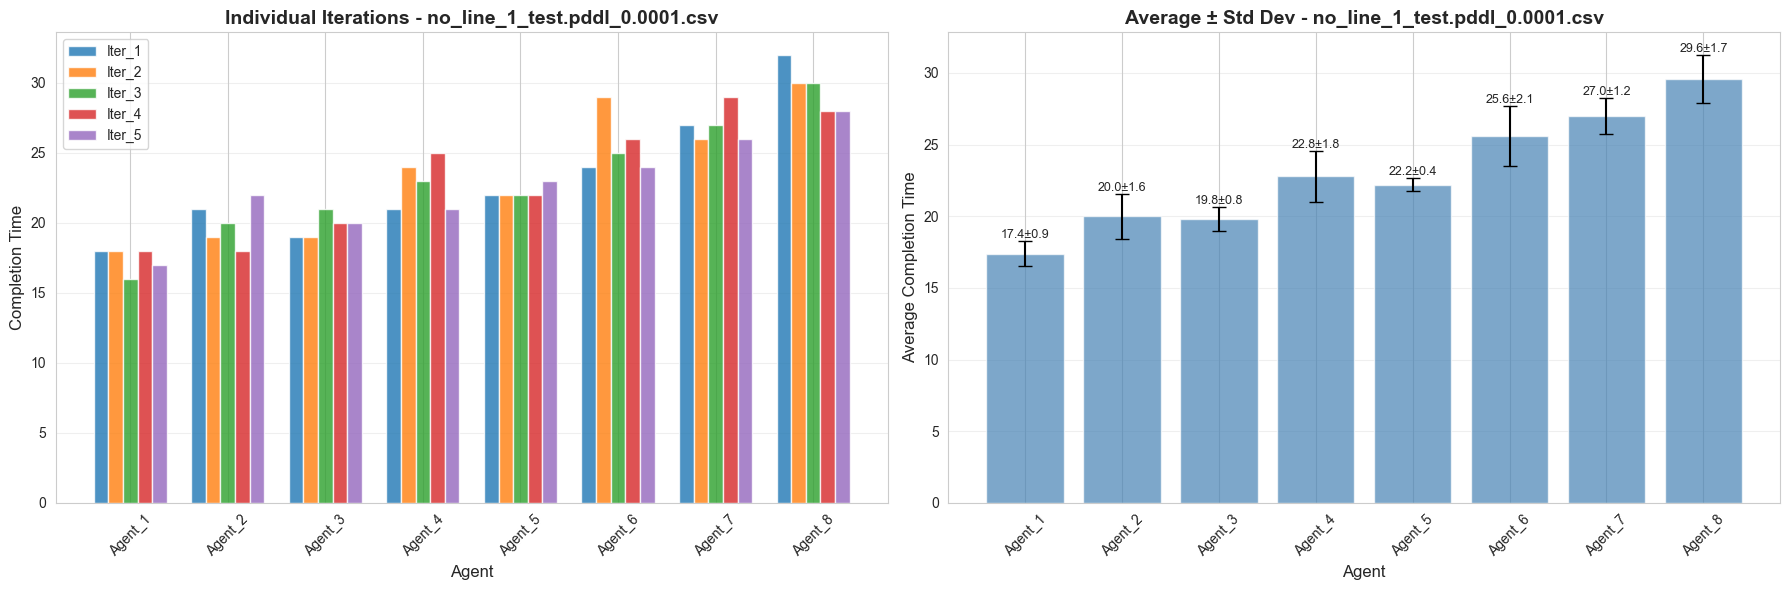

In [28]:
data = plot_single_file('level-0/no_line_1_test.pddl_0.0001_50.csv')
data2 = plot_single_file('level-1/no_line_1_test.pddl_0.0001_50.csv')
base = plot_single_file('../paper_data/no_line_1_test.pddl_0.0001.csv')